In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [3]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
# Check the data types of each column
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
# Convert TotalCharges to numeric, blank spaces become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check how many NaN values appeared
print("Missing TotalCharges values:", df['TotalCharges'].isnull().sum())

# Remove those rows - there should be exactly 11
df = df.dropna(subset=['TotalCharges'])

print("Dataset shape after fix:", df.shape)
print("TotalCharges dtype:", df['TotalCharges'].dtype)

Missing TotalCharges values: 11
Dataset shape after fix: (7032, 21)
TotalCharges dtype: float64


Churn counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64


/var/folders/nm/ww3kt8154bq9mvm1vc8dn9bw0000gn/T/ipykernel_62157/578253255.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Blues')


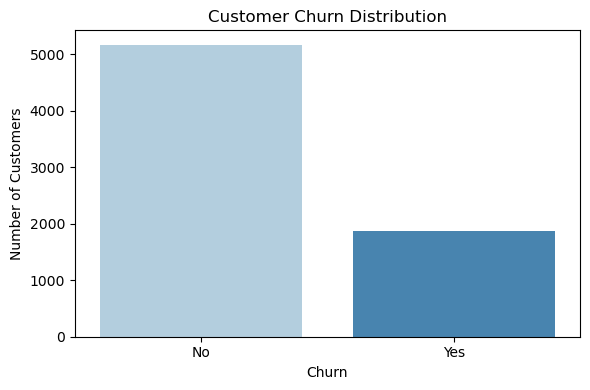

In [6]:
# Count and percentage of churn
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)
print("\nChurn percentage:")
print(churn_pct.round(1))

# Visualize it
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Blues')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

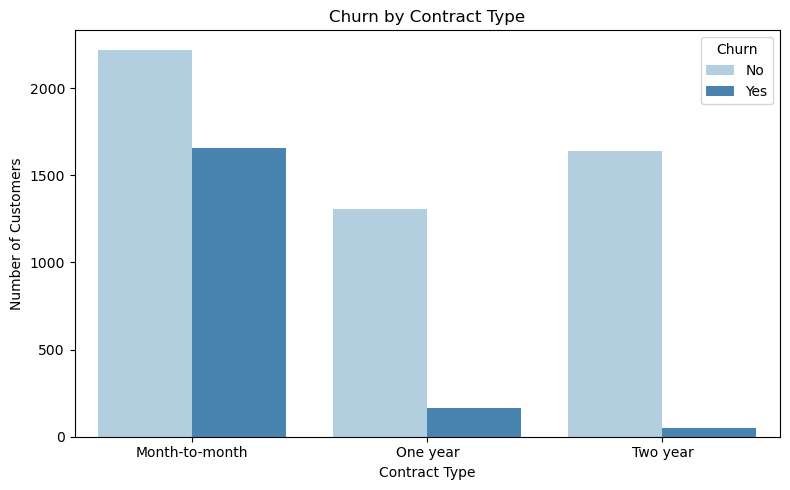

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Blues')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

In [ ]:
#Customers on month-to-month contracts churn at a dramatically higher rate 
# than those on longer contracts. Two-year contract customers show almost no churn, 
# suggesting that locking in longer commitments is the single strongest retention factor in this dataset.


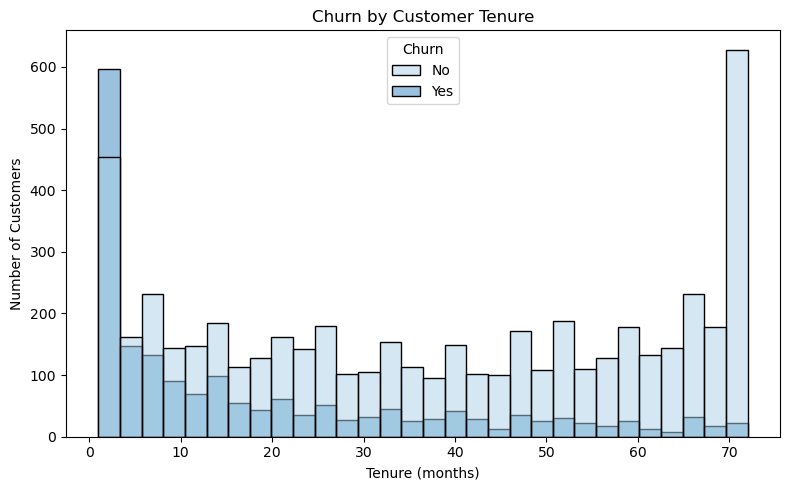

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Blues')
plt.title('Churn by Customer Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [ ]:
#Churn is heavily concentrated in the first few months. 
# Customers who survive past 12 months become increasingly loyal
# suggesting the critical retention window is early in the customer relationship.

/var/folders/nm/ww3kt8154bq9mvm1vc8dn9bw0000gn/T/ipykernel_62157/2586238761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Blues')


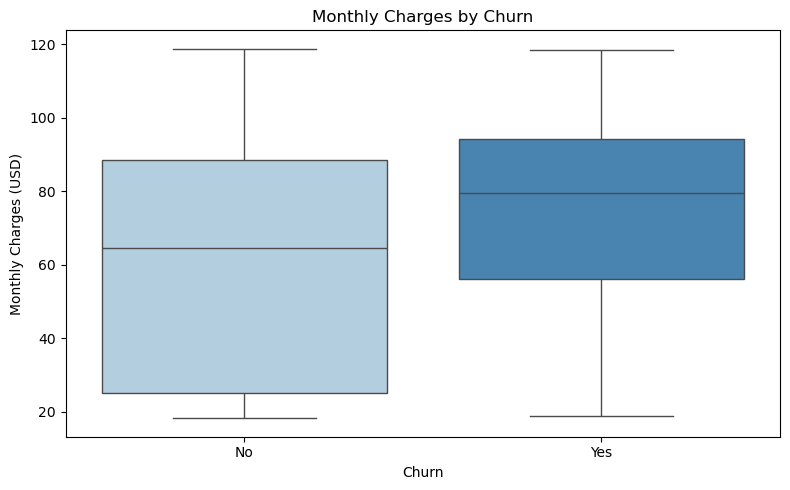

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Blues')
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges (USD)')
plt.tight_layout()
plt.show()

In [10]:
#Customers who churned were paying higher monthly charges 
# on average ($80) compared to those who stayed ($65). 
# Higher pricing is associated with a greater likelihood of leaving.

# Telecom Customer Churn Analysis

## Introduction
Customer churn — when a customer stops using a service — is one of the most 
costly problems in the telecom industry. Acquiring a new customer costs 
significantly more than retaining an existing one.

This analysis explores a telecom dataset of 7,032 customers to identify 
the key factors that drive churn. The findings are directly relevant to 
telecom network operators and their software partners.

**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Tools used:** Python, Pandas, Matplotlib, Seaborn  
**Business question:** What factors most predict customer churn?

## Key Findings

### Finding 1: Overall Churn Rate
26.6% of customers churned — more than 1 in 4. This represents a significant 
revenue risk for any telecom operator.

### Finding 2: Contract Type is the Strongest Predictor
Month-to-month customers churn at a dramatically higher rate than one-year 
or two-year contract customers. Two-year contract holders show almost no churn. 
Encouraging longer contracts is the single most effective retention strategy.

### Finding 3: New Customers are Most Vulnerable
Churn is heavily concentrated in the first few months of a customer relationship. 
Customers who stay beyond 12 months become increasingly loyal. 
The critical retention window is early in the customer lifecycle.

### Finding 4: Higher Charges Drive Churn
Customers who churned paid higher monthly charges on average (USD 80) compared 
to those who stayed (USD 65). Price sensitivity is a significant churn factor, 
particularly when combined with short-term contracts.

## Business Recommendation
Telecom operators should focus retention efforts on three groups:
1. New customers in their first 3 months
2. Month-to-month contract holders paying above $70/month
3. Customers showing early signs of dissatisfaction

Proactive outreach, loyalty discounts, and incentives to upgrade to longer 
contracts would likely reduce churn significantly.